### **Evaluation of symbolic music generation metrics<br>** *Training phase*
**Author:** Fabian Lohmann (student ID: 852760749)<br>
**Course:** Generative Artificial Intelligence (IM1412), Open University of the Netherlands<br>
*August 2026*

This notebook trains a small decoder-only transformer on the JSB-Chorales dataset using next-token prediction. It produces two files loaded by the evaluation notebook:
- `Bach_model.pt`: model weights at best validation loss
- `gen_chorales.json`: 77 chorales generated with the model

**Dataset:** JSB-Chorales (229 training / 76 validation / 77 test chorales)<br>
**Source:** https://github.com/czhuang/JSB-Chorales-dataset

Boulanger-Lewandowski, N., Vincent, P., & Bengio, Y. (2012). Modeling Temporal Dependencies in High-Dimensional Sequences: Application to Polyphonic Music Generation and Transcription. *Proceedings of the 29th International Conference on Machine Learning (ICML-12)*, 1159–1166.

**Disclaimer:** This code was written with the assistance of Claude AI. All code was rewritten, annotated, verified and fully understood by the author.

#### 1. Dependencies and dataset initialization

In [8]:
import pickle, random, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Set hyperparameters
SEED = 1427
SEQ_LEN = 256           # Context window of 256 equals 64 timesteps.
BATCH_SIZE = 64         # Optimized for 4GB VRAM
D_MODEL = 192
NHEAD = 4                   
NUM_LAYERS = 4          
DIM_FF = 768            
DROPOUT = 0.1          
LEARNING_RATE = 3e-4
EPOCHS = 40 
GEN_LENGTH = 1600       # 1600 tokens ≈ 400 timesteps ≈ 25 bars of generated music

# Initialize random seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Initialize torch device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch device: {device}')

# Load the JSB-Chorales database
with open('jsb-chorales-16th.pkl', 'rb') as p:
    data = pickle.load(p, encoding='latin1')
    
print(f'JSB-Chorales dataset loaded:')
print(f'{len(data["train"])} training, {len(data["test"])} test, {len(data["valid"])} validation chorales.')

Torch device: cuda
JSB-Chorales dataset loaded:
229 training, 77 test, 76 validation chorales.


#### 2. Tokenization
In each piece, every timestep is subdivided into four vocal parts: Soprano, Alto, Tenor, Bass (SATB). These are placed sequentially in the token list. Every timestep therefore takes up four positions.

Across all pieces 46 pitches are used (MIDI 36 to 81). These are assigned to tokens 1 to 46. Token 0 is assigned to rests, and tokens 47 and 48 to sequence boundaries.

In [9]:
# Define tokens 0 to 48
REST = 0                            # Voice is silent at this timestep
PITCH_MIN, PITCH_MAX = 36, 81       # There are 46 distinct pitches (MIDI 36-81)
BOS, EOS = 47, 48                   # Beginning of sequence, end of sequence
VOCAB_SIZE = 49                     # Total number of tokens

# Convert MIDI pitch number to corresponding token value and vice versa
def pitch_to_tok(p):
    return p - PITCH_MIN + 1
def tok_to_pitch(t):
    return None if t == REST else t + PITCH_MIN - 1

# Flatten a chorale into a sequence of tokens
def encode(chorale):
    
    # Create token sequence starting with the BOS token to indicate the start of the sequence
    toks = [BOS]
    
    # For each timestep tuple, assign all pitch tokens to the token sequence
    for timestep in chorale:
        
        # In each timestep tuple, any empty voice values are turned into "None"
        voices = list(timestep) + [None] * (4 - len(timestep))

        # Convert MIDI pitch values in voices to token sequence values, empty voice values are assigned token 0 (REST)
        for p in voices:
            if p is not None:
                toks.append(pitch_to_tok(int(p)))
            else:
                toks.append(REST)
        
    # Add the end of sequence token and return token sequence
    return toks + [EOS]     

# Convert a token sequence into a chorale
def decode(toks):
    body = [t for t in toks if t not in (BOS, EOS)]     # Remove sequence boundary markers
    body = body[:len(body) - len(body) % 4]             # Make sure the token sequence is divisible by four
    
    # Convert back into MIDI pitches and group every timestep into a tuple
    chorale = []
    for i in range(0, len(body), 4):
        timestep = tuple(tok_to_pitch(t) for t in body[i:i+4])
        chorale.append(timestep)
    return chorale

# Verify that the code is working correctly by testing an encode-decode with the first training chorale
test_chorale = [tuple(int(p) for p in timestep) for timestep in data['train'][0]]
assert all(a == b for a, b in zip(test_chorale, decode(encode(test_chorale)))), 'Encode-decode round-trip test failed.'
print('Encode-decode round-trip test successful.')

Encode-decode round-trip test successful.


#### 3. Prepare training data
Prepares for next-token prediction by dividing the chorales into chunks to set up the sliding window and sets up batches of input/target pair chunks.

In [10]:
# Divide a chorale into sliding window training chunks with SEQ_LEN + 1 positions to create SEQ_LEN training pairs
# Training stride is half the windows, so chunks overlap 50%
def make_chunks(sequences, stride):
    chunks = []
    for seq in sequences:
        for i in range(0, len(seq) - SEQ_LEN, stride):
            chunks.append(seq[i : i + SEQ_LEN + 1])
        
        # Include the final chunk at a random position so EOS and cadences appear in training without positional bias
        if len(seq) >= SEQ_LEN + 1:
            r = random.randint(0, SEQ_LEN // 2)
            chunks.append(seq[-(SEQ_LEN + 1 - r):] + [EOS] * r)
    return chunks

# Encode every training and validation chorale into tokens and divides them into chunks
train_chunks = make_chunks(
    [encode(chorale) for chorale in data['train']], stride=SEQ_LEN // 2)    # Sets training stride of 50%
valid_chunks = make_chunks(
    [encode(chorale) for chorale in data['valid']], stride=SEQ_LEN)         # Validation only works with no overlap

# Convert training and validation data to tensors
train_data = torch.tensor(train_chunks, dtype=torch.long)
valid_data = torch.tensor(valid_chunks, dtype=torch.long)

# Set up next token prediction training and validation input/target pairs
train_x, train_y = train_data[:, :-1], train_data[:, 1:]
valid_x, valid_y = valid_data[:, :-1], valid_data[:, 1:]

# Group chunks into batches to optimize for GPU processing
train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(TensorDataset(valid_x, valid_y), batch_size=BATCH_SIZE)

print(f'Training: {len(train_chunks)} examples, {len(train_loader)} batches per epoch')
print(f'Validation: {len(valid_chunks)} examples')

Training: 1665 examples, 27 batches per epoch
Validation: 336 examples


#### 4. Model architecture
Decoder-only transformer with causal masking. Hyperparameters were selected following common conventions for small-scale models. 

In [11]:
# Remove internal PyTorch optimization error that is not applicable to this setup
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor")

# Set up the transformer
class ChoralTransformer(nn.Module):
    
    # Initialize hyperparameters and set up learnable components
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT, max_len=SEQ_LEN):
        super().__init__()
        
        # Lookup table for tokens, every token ID gets a multi-dimensional vector
        self.token_emb = nn.Embedding(vocab_size, d_model)
        
        # Lookup table for positional embeddings
        self.pos_emb = nn.Embedding(max_len, d_model)
        
        # Transformer setup
        layer = nn.TransformerEncoderLayer(                                         # One transformer block
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)      # Transformer stack
        
        # Convert output embedding to logits for each token
        self.head = nn.Linear(d_model, vocab_size)

    # Forward loop
    def forward(self, x):
        
        # Identify batch size B and sequence length T from input
        B, T = x.shape
        
        # Create position indices
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        
        # Add token embeddings and positional embeddings
        x = self.token_emb(x) + self.pos_emb(pos)
        
        # Create masked matrix where tokens can only attend to past positions 
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        
        # Run input through all transformer layers and output logits
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(x)

# Create the model
model = ChoralTransformer().to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 1,847,473


#### 5. Training loop
The model is trained with AdamW optimizer using cross-entropy loss. 

The checkpoint at best validation loss is saved to `Bach_model.pt`.

In [12]:
# Set AdamW optimizer, which adds weight decay to prevent overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Set up lists for loss and variable to track the best loss
train_losses, valid_losses = [], []
best_val_loss = float('inf')        # Starts at infinity so any initial loss will be recorded as improvement

# Run through all epochs to train the model
for epoch in range(EPOCHS):
    
    # Training mode
    model.train()
    total = 0       # Keeps track of total loss
    
    # Training loop
    for x, y in train_loader:                           # Loops through all batches
        x, y = x.to(device), y.to(device)               # Move input to device
        loss = nn.functional.cross_entropy(model(x).view(-1, VOCAB_SIZE), y.view(-1))   # Calculate cross-entropy loss
        optimizer.zero_grad()                           # Clear previous gradients
        loss.backward()                                 # Backpropagation
        optimizer.step()                                # Update weights
        total += loss.item()                            # Add to total loss
    train_losses.append(total / len(train_loader))      # Average loss this epoch

    # Evaluation
    model.eval()                        # Turn off dropout
    total = 0                           # Reset total loss
    with torch.no_grad():               # Turn off gradient tracking to save memory
        for x, y in valid_loader:       # Loops through all batches to get validation loss
            x, y = x.to(device), y.to(device)
            loss = nn.functional.cross_entropy(model(x).view(-1, VOCAB_SIZE), y.view(-1))
            total += loss.item()
    valid_losses.append(total / len(valid_loader))

    # Check if this epoch's validation loss is the best so far and save the model if true
    if valid_losses[-1] < best_val_loss:
        best_val_loss = valid_losses[-1]
        torch.save(model.state_dict(), 'Bach_model.pt')

    # Every 10 epochs show loss data
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3d} | Train: {train_losses[-1]:.4f} | Valid: {valid_losses[-1]:.4f} | Best: {best_val_loss:.4f}')

print(f'\nDone. Best validation loss: {best_val_loss:.4f}')

Epoch   0 | Train: 3.0447 | Valid: 2.4259 | Best: 2.4259
Epoch  10 | Train: 0.8505 | Valid: 0.8526 | Best: 0.8526
Epoch  20 | Train: 0.6388 | Valid: 0.6638 | Best: 0.6638
Epoch  30 | Train: 0.5566 | Valid: 0.6070 | Best: 0.6070

Done. Best validation loss: 0.5851


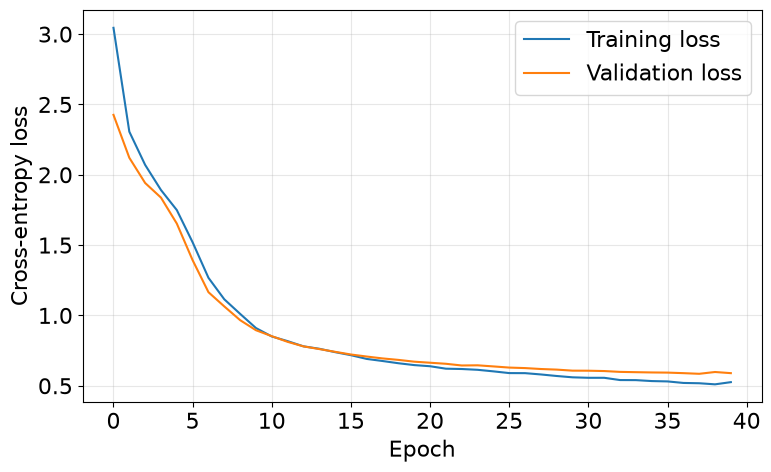

Saved to training_curves.pdf


In [ ]:
# Plot the training and validation loss for visualization
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.pdf', dpi=150)
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved to training_curves.pdf')

#### 6. Generate chorales
Generates 77 chorales to match the test set size. The chorales are generated through autoregressive sampling and are saved to `gen_chorales.json`.

In [14]:
# Load the model and turn off dropout
model.load_state_dict(torch.load('Bach_model.pt'))
model.eval()

# Autoregressive sampling
def generate(model, length=GEN_LENGTH, temperature=1.0):
    tokens = [BOS]                      # Start token sequence with beginning of sequence token
    with torch.no_grad():               # Turn off gradient tracking to save memory
        for _ in range(length):         # Iterate through loop, adds one token per iteration
            x = torch.tensor([tokens[-SEQ_LEN:]], device=device)  
            logits = model(x)[0, -1] / temperature
            logits[BOS] = float('-inf')         # Prevent BOS from being sampled mid-sequence
            token = torch.multinomial(torch.softmax(logits, dim=-1), 1).item()
            if token == EOS:            # If the model predicts end of sequence, stop generating
                break
            tokens.append(token)        # Add token to token sequence
    return tokens

# Run the autoregressive sampling loop to generate 77 chorales and decode into SATB tuples
gen_chorales = [decode(generate(model, length=GEN_LENGTH, temperature=1.0)) for _ in range(77)]

# Save all 77 choraless to json
with open('gen_chorales.json', 'w') as f:
    json.dump(gen_chorales, f)
    
# Check how many of the chorales ended with the EOS token
natural = sum(1 for ch in gen_chorales if len(ch) < 399)
print(f'EOS endings: {natural}/{len(gen_chorales)}')
print(f'Saved.')

print(f'Saved {len(gen_chorales)} generated chorales to gen_chorales.json')

EOS endings: 76/77
Saved.
Saved 77 generated chorales to gen_chorales.json
